# Colorado — Facility Occurrences EDA
**Source:** CO Dept of Public Health & Environment, Data Request — Michael Nolan (2026-03-30)
**Dataset:** Facility reportable occurrence reports, CY 2023–2025
**Rows:** ~10,477 | **Facility types:** SNF, ALR, Short-Term Hospital, Psychiatric, RCFDD, HCA…

This notebook explores Colorado's mandatory facility occurrence reports under CRS §25-1-124.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
FILE = ('Colorado/CO - Data_Request_-_Michael_Nolan-_03.30.2026_-_'
        'Facility_Occurrences_CY_23-25xlsx.xlsx - Data.csv')
co = pd.read_csv(FILE)

co['Occurrence Date'] = pd.to_datetime(co['Occurrence Date'], errors='coerce')
co['year']  = co['Occurrence Date'].dt.year
co['month'] = co['Occurrence Date'].dt.to_period('M')

print(f"Rows: {len(co):,}  |  Columns: {list(co.columns)}")
co.head(2)


Rows: 10,477  |  Columns: ['Facility ID', 'Facility Name', 'Facility Type Code', 'Facility Type Name', 'Facility Type Abbreviation', 'Facility Admin Name', 'Bed License Total', 'Owner Company', 'Facility Operating Status', 'Facility Address', 'Facility County', 'Facility City', 'Facility Phone', 'Occurrence ID', 'Type of Occurrence', 'Occurrence Date', 'Occurrence Description', 'Occurrence Description_Overflow1', 'year', 'month']


,Facility ID,Facility Name,Facility Type Code,Facility Type Name,Facility Type Abbreviation,Facility Admin Name,Bed License Total,Owner Company,Facility Operating Status,Facility Address,Facility County,Facility City,Facility Phone,Occurrence ID,Type of Occurrence,Occurrence Date,Occurrence Description,Occurrence Description_Overflow1,year,month
0,10C962,# 1 HOME CARE AGENCY CORPORATION,05D,Home Care Agency-Personal Care/Homemaker (Medi...,HCA-PHS,"Vaynshteyn, Samuil",0,# 1 HOME CARE AGENCY CORPORATION,Active,"10200 E GIRARD AVE BLDG A STE 103, DENVER, CO...",Denver,DENVER,(303) 306-0404,2310C962001,Misappropriation of Property,2023-04-24,"DESCRIPTION OF OCCURRENCE: On 4/24/23, a clie...",NaN,2023,2023-04
1,0506AT,198 E GALATEA,S41,Residential Care Facility for the Developmenta...,RCF-DD,"De Maria, Jacqueline (JR)",8,STATE OF COLORADO,Active,"198 E GALATEA DR, PUEBLO WEST, CO 81007-",Pueblo,PUEBLO WEST,(719) 585-4001,230506AT001,Neglect,2023-03-14,"DESCRIPTION OF OCCURRENCE: On 3/14/23, a staf...",NaN,2023,2023-03


In [3]:
# ── Overview ────────────────────────────────────────────────────────────────
print("=== Missing values ===")
print(co.isnull().sum())
print()
print(f"Date range: {co['Occurrence Date'].min().date()} → {co['Occurrence Date'].max().date()}")
print(f"Unique facilities: {co['Facility ID'].nunique():,}")
print(f"Unique occurrence types: {co['Type of Occurrence'].nunique()}")


=== Missing values ===
Facility ID                             0
Facility Name                           0
Facility Type Code                      0
Facility Type Name                      0
Facility Type Abbreviation              0
Facility Admin Name                     0
Bed License Total                       0
Owner Company                           0
Facility Operating Status               0
Facility Address                        0
Facility County                         0
Facility City                           0
Facility Phone                          0
Occurrence ID                           0
Type of Occurrence                      0
Occurrence Date                         0
Occurrence Description                  3
Occurrence Description_Overflow1    10444
year                                    0
month                                   0
dtype: int64

Date range: 2023-01-01 → 2024-12-31
Unique facilities: 982
Unique occurrence types: 15


## 1 · Occurrence Type Distribution

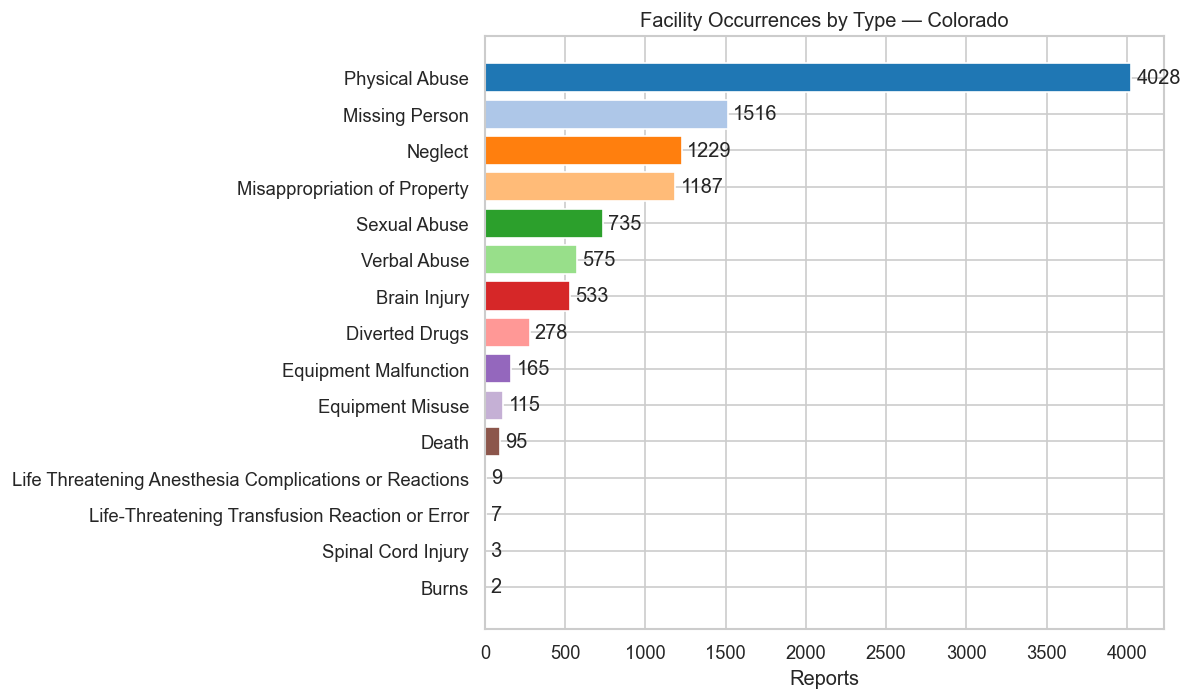

                                                    count   pct
Type of Occurrence                                             
Physical Abuse                                       4028  38.4
Missing Person                                       1516  14.5
Neglect                                              1229  11.7
Misappropriation of Property                         1187  11.3
Sexual Abuse                                          735   7.0
Verbal Abuse                                          575   5.5
Brain Injury                                          533   5.1
Diverted Drugs                                        278   2.7
Equipment Malfunction                                 165   1.6
Equipment Misuse                                      115   1.1
Death                                                  95   0.9
Life Threatening Anesthesia Complications or Re...      9   0.1
Life-Threatening Transfusion Reaction or Error          7   0.1
Spinal Cord Injury                      

In [4]:
occ_type = co['Type of Occurrence'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(occ_type.index, occ_type.values, color=sns.color_palette('tab20', len(occ_type)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Reports')
ax.set_title('Facility Occurrences by Type — Colorado')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

total = occ_type.sum()
print(occ_type.to_frame('count').assign(pct=lambda d: (d['count']/total*100).round(1)))


## 2 · Monthly Occurrence Trend

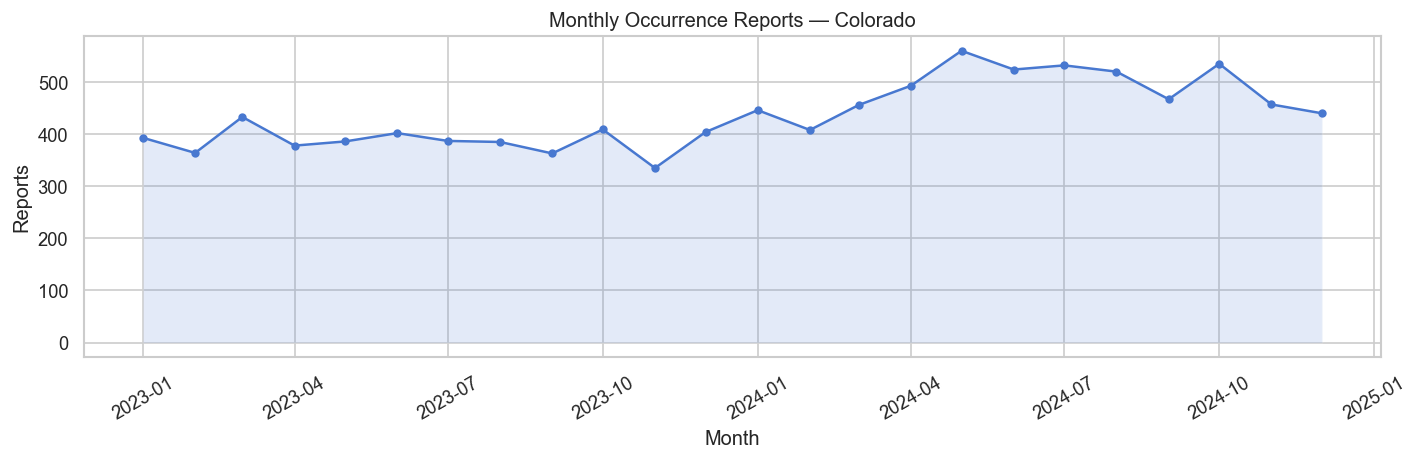

In [5]:
monthly = co.groupby('month').size().reset_index(name='count')
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['month_dt'], monthly['count'], marker='o', linewidth=1.5, markersize=4)
ax.fill_between(monthly['month_dt'], monthly['count'], alpha=0.15)
ax.set_title('Monthly Occurrence Reports — Colorado')
ax.set_xlabel('Month')
ax.set_ylabel('Reports')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3 · Facility Type Breakdown

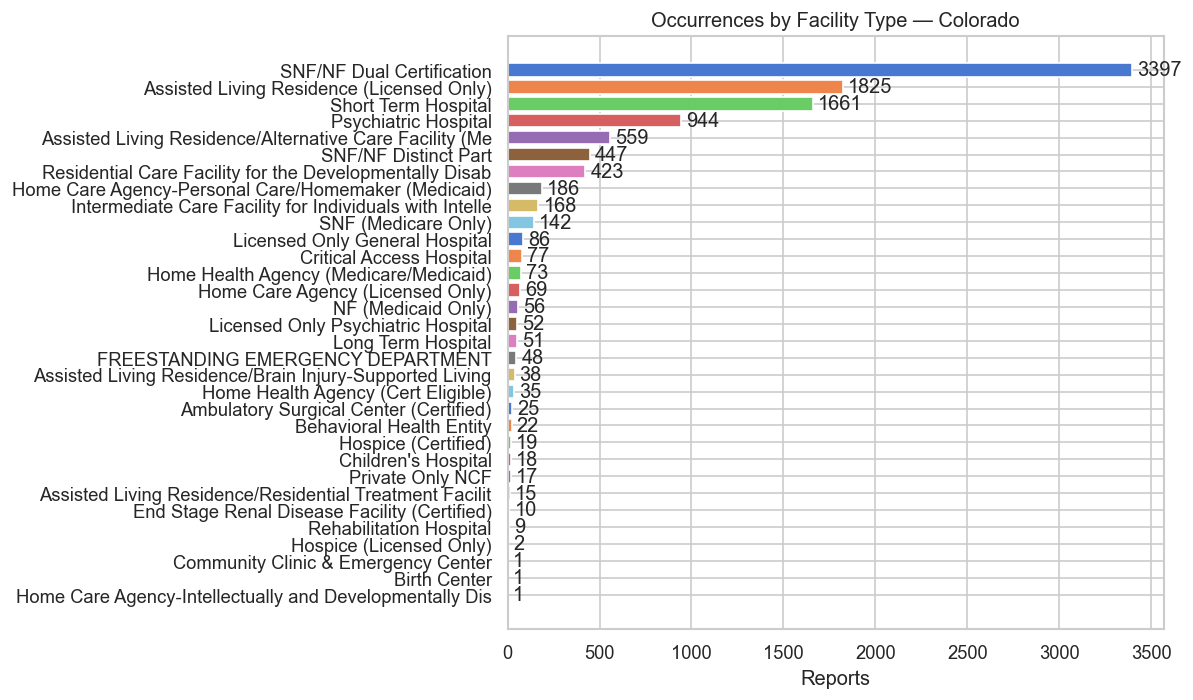

In [6]:
fac_type = co['Facility Type Name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fac_type.index.str[:55], fac_type.values, color=sns.color_palette('muted', len(fac_type)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Reports')
ax.set_title('Occurrences by Facility Type — Colorado')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4 · County Heatmap — Top 15 Counties

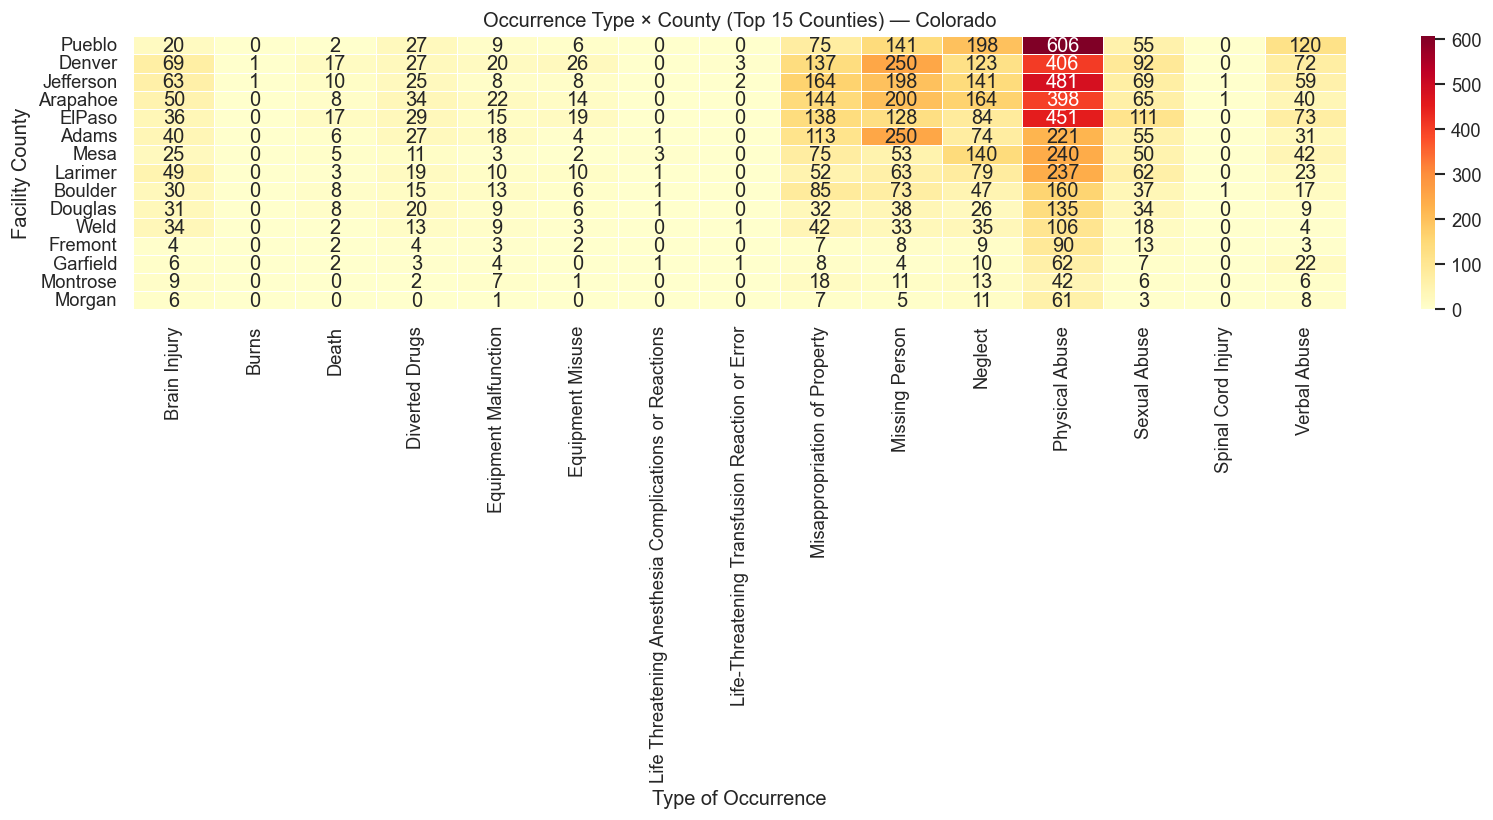

In [7]:
county_type = co.groupby(['Facility County', 'Type of Occurrence']).size().unstack(fill_value=0)
top15_counties = co['Facility County'].value_counts().head(15).index
county_type = county_type.loc[top15_counties]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(county_type, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Occurrence Type × County (Top 15 Counties) — Colorado')
plt.tight_layout()
plt.show()


## 5 · Top 20 Facilities by Report Count

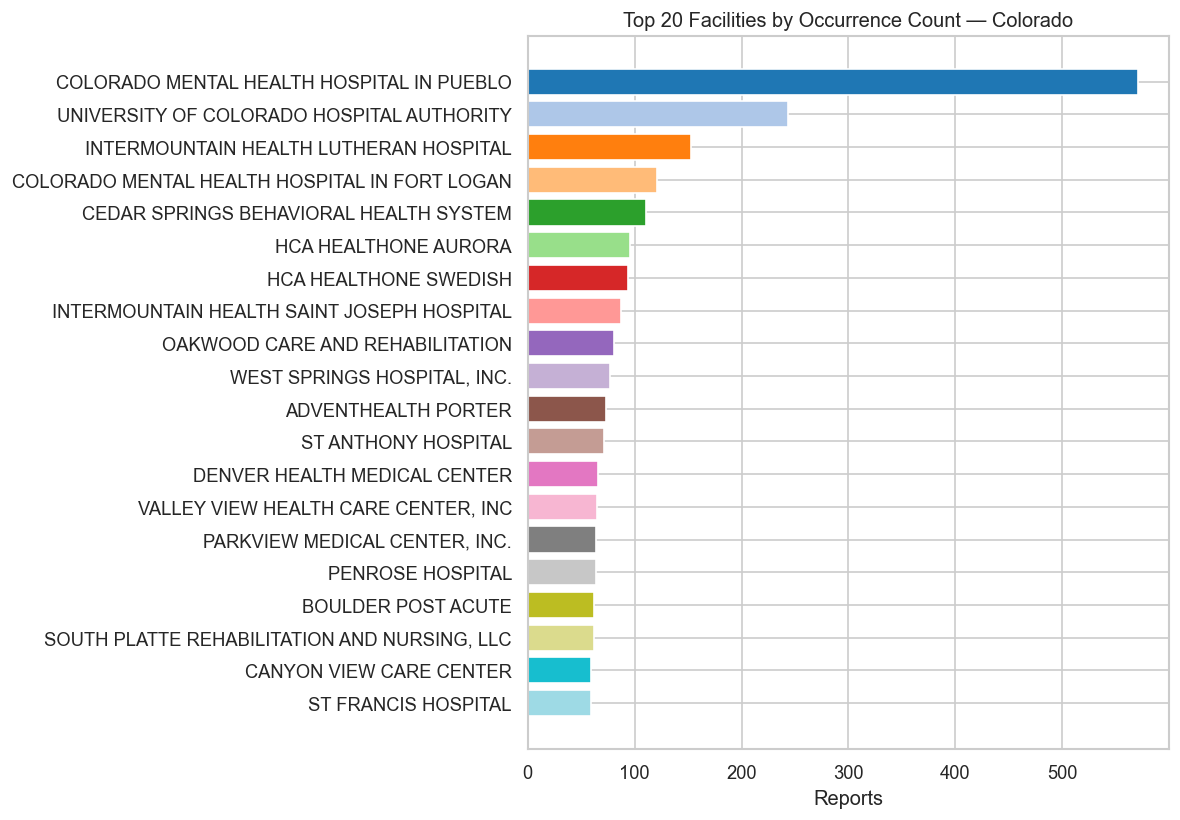

In [8]:
top_fac = (co.groupby(['Facility Name', 'Facility Type Name'])
            .size().reset_index(name='count')
            .nlargest(20, 'count'))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_fac['Facility Name'].str[:50], top_fac['count'],
        color=sns.color_palette('tab20', 20))
ax.set_xlabel('Reports')
ax.set_title('Top 20 Facilities by Occurrence Count — Colorado')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6 · Facility Operating Status

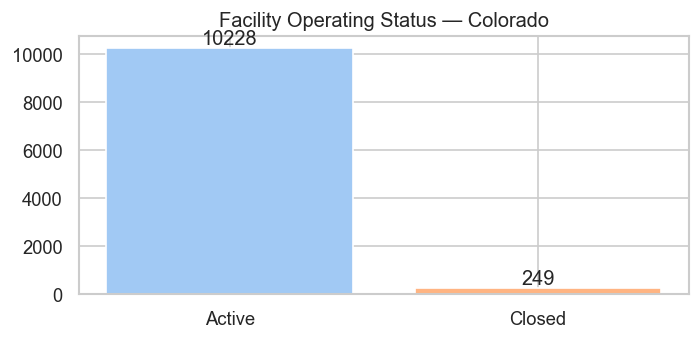

In [9]:
status = co['Facility Operating Status'].value_counts()
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(status.index, status.values, color=sns.color_palette('pastel', len(status)))
ax.bar_label(bars)
ax.set_title('Facility Operating Status — Colorado')
plt.tight_layout()
plt.show()


## 7 · Year-over-Year Occurrence Types

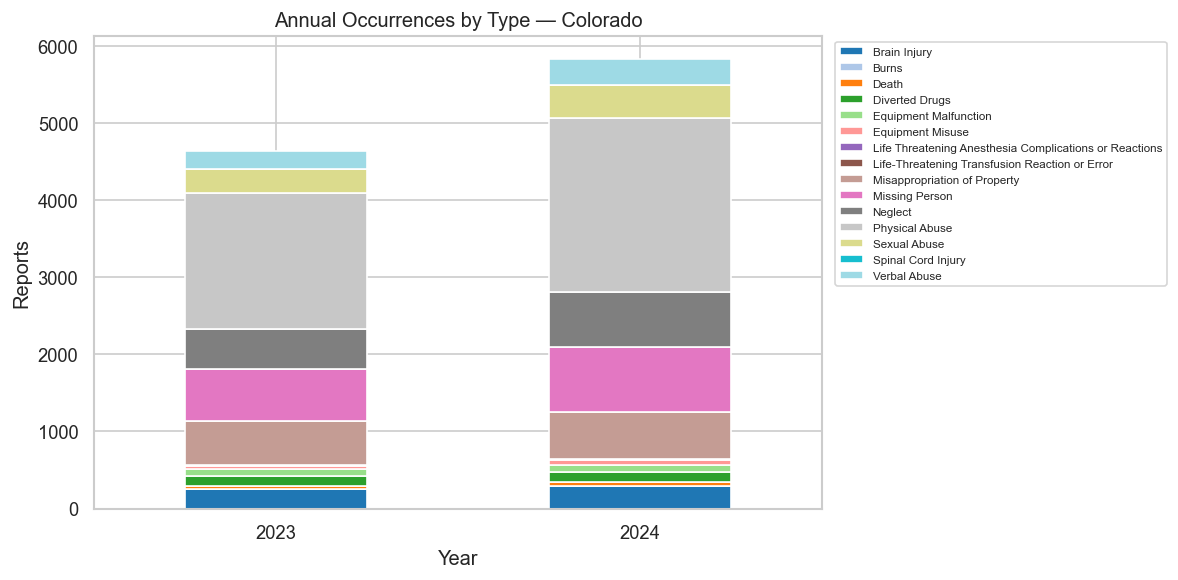

In [10]:
yoy = co.groupby(['year', 'Type of Occurrence']).size().unstack(fill_value=0)

ax = yoy.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
ax.set_title('Annual Occurrences by Type — Colorado')
ax.set_xlabel('Year')
ax.set_ylabel('Reports')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8 · Bed Capacity Distribution (Active Facilities)

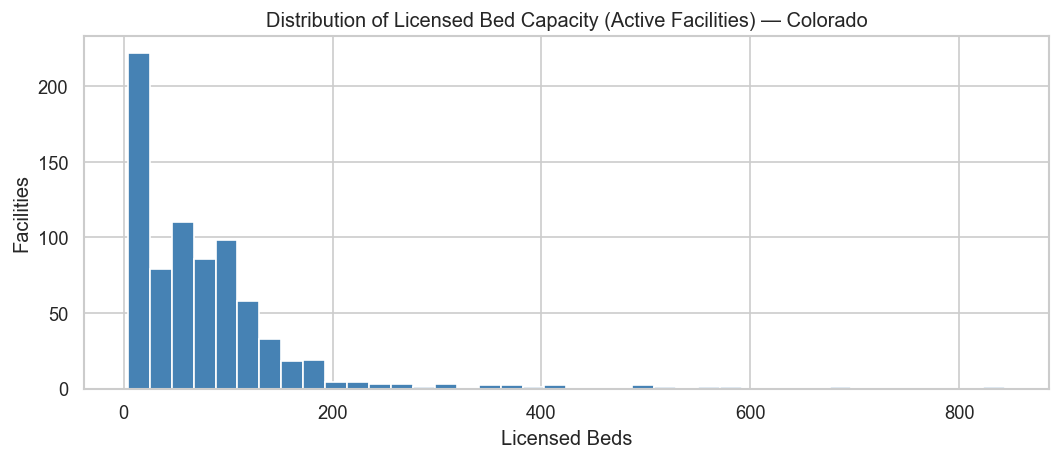

count    755.000000
mean      75.047682
std       81.102600
min        4.000000
25%       16.000000
50%       60.000000
75%      103.000000
max      844.000000
Name: Bed License Total, dtype: float64


In [11]:
active = co[co['Facility Operating Status'] == 'Active'].drop_duplicates('Facility ID')
beds = active[active['Bed License Total'] > 0]['Bed License Total']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(beds, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Licensed Beds')
ax.set_ylabel('Facilities')
ax.set_title('Distribution of Licensed Bed Capacity (Active Facilities) — Colorado')
plt.tight_layout()
plt.show()

print(beds.describe())


## 9 · Occurrence Type × Facility Type

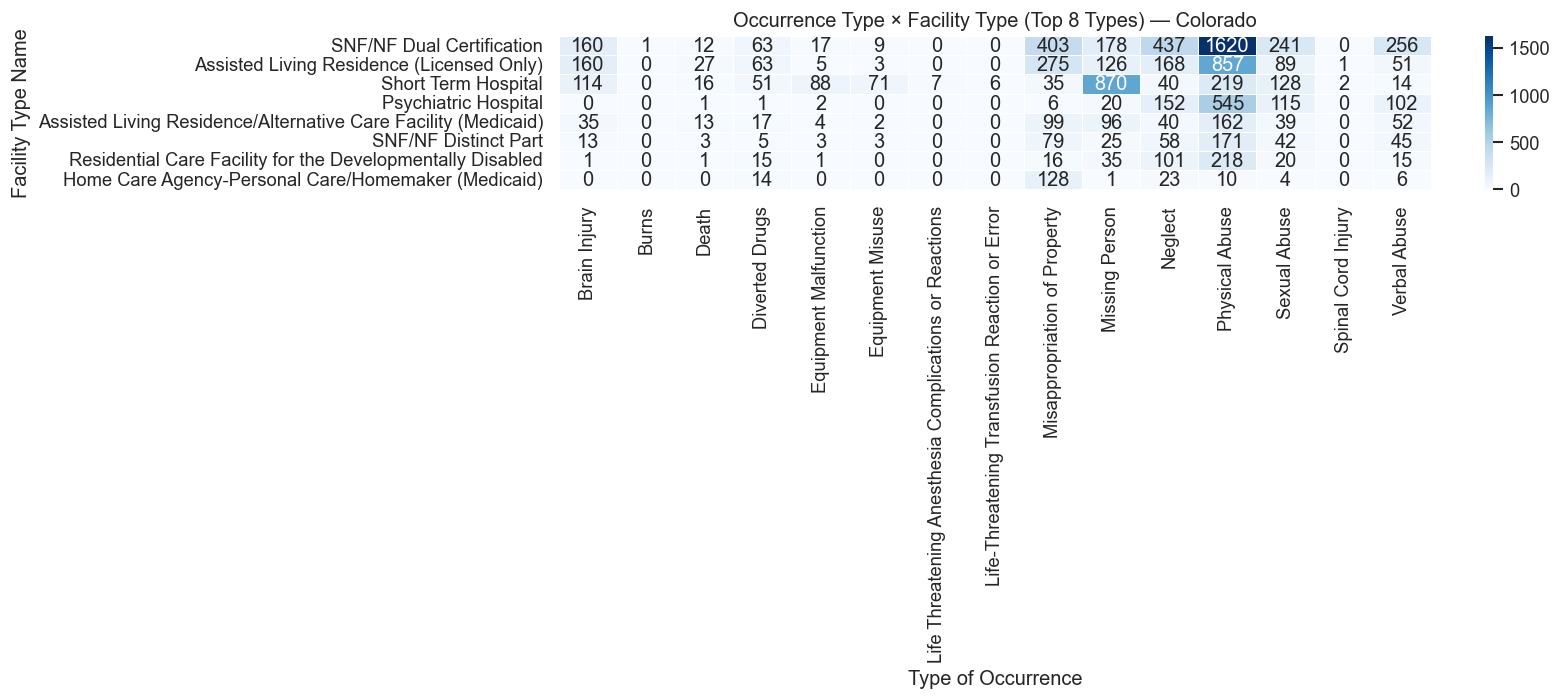

In [12]:
ct = co.groupby(['Facility Type Name', 'Type of Occurrence']).size().unstack(fill_value=0)
# Keep top 8 facility types
top8_ft = co['Facility Type Name'].value_counts().head(8).index
ct = ct.loc[top8_ft]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.3, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Occurrence Type × Facility Type (Top 8 Types) — Colorado')
plt.tight_layout()
plt.show()
